# Homework #2: ProShares Replication
**Course:** Portfolio and Risk Management  
**Group / names:** Group A / Alexei Le, Jennifer Xiao, Ivy Chan, Edouard Lavalard


## Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
from sklearn.linear_model import LinearRegression

pd.set_option('display.float_format', '{:,.4f}'.format)
pd.set_option('display.width', 200)

In [3]:
FILE = 'proshares_analysis_data.xlsx'

hf  = pd.read_excel(FILE, sheet_name='hedge_fund_series', index_col=0)   # HFRI, MLFM, MLFM-ES, HDG, QAI
fac = pd.read_excel(FILE, sheet_name='merrill_factors',   index_col=0)   # SPY, T-bill, EEM, EFA, EUO, IWM
oth = pd.read_excel(FILE, sheet_name='other_data',        index_col=0)   # TRVCI, HEFA, TAIL, SPXU, UPRO

rf = fac['USGG3M Index']   # monthly 3-month T-bill return
PER = 12                   # periods per year (monthly data)

### Data checks
The series are **total returns** (not excess). `USGG3M` is also one of the six Merrill factors, so it stays in `fac` for the replication regressions. HEFA and TAIL start late and HFRI has no value for the last month.

In [4]:
for name, d in [('hedge_fund_series', hf), ('merrill_factors', fac), ('other_data', oth)]:
    print(f'{name}: {d.shape}, {d.index.min().date()} to {d.index.max().date()}')
print('Same dates across tabs:', hf.index.equals(fac.index) and hf.index.equals(oth.index))
print()
print('Non-missing observations per series:')
pd.concat([hf, fac, oth], axis=1).count()

hedge_fund_series: (170, 5), 2011-08-31 to 2025-09-30
merrill_factors: (170, 6), 2011-08-31 to 2025-09-30
other_data: (170, 5), 2011-08-31 to 2025-09-30
Same dates across tabs: True

Non-missing observations per series:


HFRIFWI Index     169
MLEIFCTR Index    170
MLEIFCTX Index    170
HDG US Equity     170
QAI US Equity     170
SPY US Equity     170
USGG3M Index      170
EEM US Equity     170
EFA US Equity     170
EUO US Equity     170
IWM US Equity     170
TRVCI Index       170
HEFA US Equity    139
TAIL US Equity    101
SPXU US Equity    170
UPRO US Equity    170
dtype: int64

### Helper functions


In [12]:
def summary_stats(df, rf=rf, per=PER):
    """Annualized mean (total return), volatility, and Sharpe ratio on excess-over-T-bill returns."""
    out = {}
    for c in df:
        r = df[c].dropna()
        ex = r - rf.reindex(r.index)
        out[c] = {'Mean (ann.)': r.mean() * per,
                  'Vol (ann.)': r.std() * np.sqrt(per),
                  'Sharpe (ann.)': ex.mean() * per / (ex.std() * np.sqrt(per))}
    return pd.DataFrame(out).T


def max_drawdown(r):
    """Max drawdown of a return series, with peak, trough and recovery dates."""
    r = r.dropna()
    wealth = (1 + r).cumprod()                 # compounded wealth index
    peak = wealth.cummax()
    dd = wealth / peak - 1
    trough = dd.idxmin()
    peak_date = wealth.loc[:trough].idxmax()   # last running high before the trough
    after = wealth.loc[trough:]
    rec = after[after >= wealth.loc[peak_date]]
    recovery = rec.index[0] if len(rec) else pd.NaT   # NaT = never recovered
    return dd.min(), peak_date, trough, recovery


def tail_stats(df, q=0.05):
    out = {}
    for c in df:
        r = df[c].dropna()
        var = r.quantile(q)
        mdd, pk, tr, rc = max_drawdown(r)
        out[c] = {'Skewness': stats.skew(r),
                  'Excess kurtosis': stats.kurtosis(r),     # scipy default is already excess (normal = 0)
                  'VaR (5%)': var,
                  'CVaR (5%)': r[r <= var].mean(),
                  'Max drawdown': mdd,
                  'Peak date': pk.date(), 'Trough date': tr.date(),
                  'Recovery date': rc.date() if pd.notna(rc) else 'not recovered'}
    return pd.DataFrame(out).T

def reg_stats(df, mkt=fac['SPY US Equity'], rf=rf, per=PER):
    """Regress each series' excess return on SPY's excess return (with intercept)."""
    out = {}
    for c in df:
        d = pd.concat([df[c] - rf, mkt - rf], axis=1, keys=['y', 'x']).dropna()
        res = sm.OLS(d['y'], sm.add_constant(d['x'])).fit()
        alpha, beta = res.params['const'], res.params['x']
        out[c] = {'Alpha (ann.)': alpha * per,
                  'Beta': beta,
                  'Treynor (ann.)': d['y'].mean() * per / beta,
                  'Info ratio (ann.)': alpha * per / (res.resid.std() * np.sqrt(per)),
                  'R-squared': res.rsquared}
    return pd.DataFrame(out).T

## 2.1 Summary statistics

In [11]:
summary_stats(hf)

,Mean (ann.),Vol (ann.),Sharpe (ann.)
HFRIFWI Index,0.0513,0.0588,0.6184
MLEIFCTR Index,0.0385,0.0552,0.4257
MLEIFCTX Index,0.0365,0.0551,0.3899
HDG US Equity,0.0269,0.0574,0.2060
QAI US Equity,0.0288,0.0498,0.2779


Means are monthly means x 12, volatilities are monthly standard deviations x sqrt(12), and the Sharpe ratio is the annualized mean excess return over the 3-month T-bill (USGG3M) divided by annualized volatility of excess returns. The mean column is the total return. The sample is Aug 2011 to Sep 2025, except HFRI, which has no value for Sep 2025 (169 months).



| Series | Mean | Volatility | Sharpe |
|---|---|---|---|
| HFRI | 5.13% | 5.88% | 0.62 |
| MLFM | 3.85% | 5.52% | 0.43 |
| MLFM-ES | 3.65% | 5.51% | 0.39 |
| HDG | 2.69% | 5.74% | 0.21 |
| QAI | 2.88% | 4.98% | 0.28 |

HFRI has the highest mean and Sharpe ratio. The replicators have similar volatility to HFRI (about 5.5%) but earn 1.3 to 2.4 percentage points less per year, so their Sharpe ratios are lower. HDG trails MLFM-ES by about 1 percentage point, close to its expense ratio. QAI has the lowest volatility but a lower Sharpe than HFRI and the Merrill series.

## 2.2 Tail risk

In [9]:
tail_stats(hf)

,Skewness,Excess kurtosis,VaR (5%),CVaR (5%),Max drawdown,Peak date,Trough date,Recovery date
HFRIFWI Index,-0.9398,5.4561,-0.0240,-0.0360,-0.1155,2019-12-31,2020-03-31,2020-08-31
MLEIFCTR Index,-0.2874,1.5483,-0.0270,-0.0350,-0.1243,2021-06-30,2022-09-30,2024-02-29
MLEIFCTX Index,-0.2711,1.5083,-0.0270,-0.0349,-0.1244,2021-06-30,2022-09-30,2024-02-29
HDG US Equity,-0.2725,1.6896,-0.0299,-0.0368,-0.1407,2021-06-30,2022-09-30,2024-07-31
QAI US Equity,-0.4297,1.3718,-0.0172,-0.0310,-0.1377,2021-06-30,2022-09-30,2024-02-29


Skewness and excess kurtosis come from scipy (excess kurtosis is relative to a normal distribution, so a normal gives 0). VaR is the 5th percentile of monthly returns, and CVaR is the mean of returns at or below it (only about 9 observations, so it is noisy). Drawdowns are computed on compounded wealth: the peak is the last running high before the trough, and recovery is the first month wealth returns to that peak. None of these are annualized.


| Series | Skew | Excess kurt. | VaR 5% | CVaR 5% | Max drawdown | Peak | Trough | Recovery |
|---|---|---|---|---|---|---|---|---|
| HFRI | -0.94 | 5.46 | -2.40% | -3.60% | -11.5% | Dec 2019 | Mar 2020 | Aug 2020 |
| MLFM | -0.29 | 1.55 | -2.70% | -3.50% | -12.4% | Jun 2021 | Sep 2022 | Feb 2024 |
| MLFM-ES | -0.27 | 1.51 | -2.70% | -3.49% | -12.4% | Jun 2021 | Sep 2022 | Feb 2024 |
| HDG | -0.27 | 1.69 | -2.99% | -3.68% | -14.1% | Jun 2021 | Sep 2022 | Jul 2024 |
| QAI | -0.43 | 1.37 | -1.72% | -3.10% | -13.8% | Jun 2021 | Sep 2022 | Feb 2024 |

HFRI has a fat, negatively skewed tail (excess kurtosis 5.5, skew -0.94), driven by the March 2020 crash, from which it recovered within five months. The replicators (MLFM, MLFM-ES, HDG) are much less skewed and fat-tailed, and their worst drawdown is instead the long 2021 to 2024 decline. HDG has the largest drawdown and VaR of the group.

## 2.3 Regressions vs SPY

In [13]:
reg_stats(hf)

,Alpha (ann.),Beta,Treynor (ann.),Info ratio (ann.),R-squared
HFRIFWI Index,-0.0080,0.3461,0.1050,-0.2552,0.7153
MLEIFCTR Index,-0.0209,0.3419,0.0686,-0.8288,0.7909
MLEIFCTX Index,-0.0228,0.3409,0.0629,-0.9029,0.7897
HDG US Equity,-0.0336,0.3500,0.0337,-1.2167,0.7675
QAI US Equity,-0.0252,0.3001,0.0457,-1.0371,0.7582


For each series, I regress its monthly excess return (over the 3-month T-bill) on SPY's monthly excess return with an intercept. Beta is the slope. The Treynor ratio is the annualized mean excess return divided by beta. The information ratio is annualized alpha (monthly alpha x 12) divided by annualized residual volatility (monthly residual standard deviation x sqrt(12)).


| Series | Alpha | Beta | Treynor | Info ratio | R-squared |
|---|---|---|---|---|---|
| HFRI | -0.80% | 0.35 | 10.5% | -0.26 | 0.72 |
| MLFM | -2.09% | 0.34 | 6.9% | -0.83 | 0.79 |
| MLFM-ES | -2.28% | 0.34 | 6.3% | -0.90 | 0.79 |
| HDG | -3.36% | 0.35 | 3.4% | -1.22 | 0.77 |
| QAI | -2.52% | 0.30 | 4.6% | -1.04 | 0.76 |

Every series has a beta of about 0.3 to 0.35 to SPY, so each carries roughly a third of the market's exposure. All alphas are negative, and HFRI's is the smallest. The replicators and ETFs trail HFRI on both Treynor and information ratio. For comparison, SPY's own Treynor ratio equals its mean excess return, about 13.0%, higher than any of these series.

## 2.4 Discussion

In [14]:
spy = fac[['SPY US Equity']]
display(summary_stats(spy))
display(tail_stats(spy))

,Mean (ann.),Vol (ann.),Sharpe (ann.)
SPY US Equity,0.1447,0.1434,0.9048


,Skewness,Excess kurtosis,VaR (5%),CVaR (5%),Max drawdown,Peak date,Trough date,Recovery date
SPY US Equity,-0.4089,0.6488,-0.0625,-0.0841,-0.2393,2021-12-31,2022-09-30,2023-12-31


**SPY versus the hedge-fund series.** SPY returned about 14.5% a year (13.0% in excess of T-bills) with 14.3% volatility, a Sharpe ratio of 0.90 and a maximum drawdown of -23.9%. The hedge-fund series are far less risky but also far less rewarding: HFRI earned 5.1% with 5.9% volatility, and the other series earned 2.7% to 3.9% with 5.0% to 5.7% volatility. Their 5% VaR is only -1.7% to -3.0% per month versus -6.3% for SPY, and their worst drawdowns are -11% to -14% versus -24%. Each series has a market beta of only 0.30 to 0.35, and SPY explains 72% to 79% of their variance (R-squared), so they are largely a diluted version of equity exposure. All of their alphas against SPY are negative (HFRI -0.8%; the others -2.1% to -3.4%), and their Treynor ratios (3.4% to 10.5%) are all well below SPY's own 13.0%. Their Sharpe ratios (0.21 to 0.62) are also all below SPY's 0.90. Over this sample, which includes a long equity bull market, hedge funds worked as lower-risk, lower-return diversifiers, not as a source of better risk-adjusted performance.

**HDG versus QAI.** QAI performs better. It has a slightly higher mean (2.88% versus 2.69%) with lower volatility (4.98% versus 5.74%), giving a higher Sharpe ratio (0.28 versus 0.21). It also has a smaller 5% VaR (-1.72% versus -2.99%) and CVaR (-3.10% versus -3.68%), a lower beta (0.30 versus 0.35), a higher Treynor ratio (4.6% versus 3.4%) and a less negative information ratio (-1.04 versus -1.22). The maximum drawdowns are similar (-13.8% for QAI, -14.1% for HDG). HDG is slightly less negatively skewed (-0.27 versus -0.43), but this does not offset QAI's advantages. Both lag HFRI, and the gaps are modest relative to the short sample.

**Do HDG and the Merrill Lynch series capture HFRI's notable properties?** Partly. They match HFRI's low volatility (5.5% to 5.7% versus 5.9%) and its low market beta (0.34 to 0.35 versus 0.35). They do not capture its level of return or its risk-adjusted performance: mean returns are 1.3 to 2.4 percentage points lower per year, Sharpe ratios are 0.21 to 0.43 versus 0.62, and alphas against SPY are much more negative. The tail behavior also differs. HFRI has a fat, negatively skewed distribution (skewness -0.94, excess kurtosis 5.5) driven by the March 2020 crash, while MLFM, MLFM-ES and HDG are much less skewed and fat-tailed (skewness about -0.27 to -0.29, excess kurtosis 1.5 to 1.7). Their worst drawdowns occur in 2021 to 2022 and take until 2024 to recover, whereas HFRI's worst drawdown was the quick 2020 crash. MLFM and MLFM-ES are almost identical to each other, and HDG tracks MLFM-ES with a roughly 1 percentage point shortfall per year, consistent with its fees. So the replicators capture the market exposure and volatility of hedge funds, but not their returns or their tail risk.

## 2.5 Correlations

,HFRI,MLFM,MLFM-ES,HDG,QAI,SPY
HFRI,1.0000,0.9005,0.8999,0.8900,0.8578,0.8463
MLFM,0.9005,1.0000,0.9999,0.9879,0.8936,0.8891
MLFM-ES,0.8999,0.9999,1.0000,0.9877,0.8934,0.8887
HDG,0.8900,0.9879,0.9877,1.0000,0.8793,0.8760
QAI,0.8578,0.8936,0.8934,0.8793,1.0000,0.8675
SPY,0.8463,0.8891,0.8887,0.8760,0.8675,1.0000


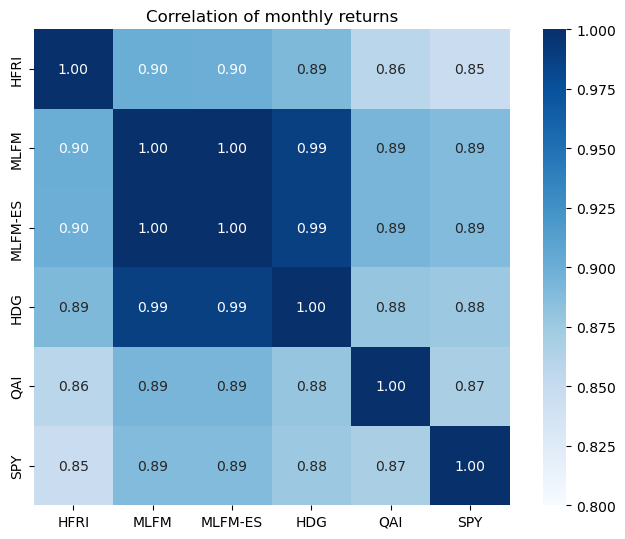

Lowest : ('HFRI', 'SPY') 0.846
Highest: ('MLFM', 'MLFM-ES') 1.0


In [15]:
assets = pd.concat([hf, fac[['SPY US Equity']]], axis=1)
assets = assets.rename(columns={'HFRIFWI Index': 'HFRI', 'MLEIFCTR Index': 'MLFM',
                                'MLEIFCTX Index': 'MLFM-ES', 'HDG US Equity': 'HDG',
                                'QAI US Equity': 'QAI', 'SPY US Equity': 'SPY'})
corr = assets.corr()
display(corr)

plt.figure(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues', vmin=0.8, vmax=1, square=True)
plt.title('Correlation of monthly returns')
plt.tight_layout()
plt.show()

# Highest / lowest pair, excluding the diagonal
pairs = corr.where(~np.eye(len(corr), dtype=bool)).stack()
pairs = pairs[[a < b for a, b in pairs.index]].sort_values()
print('Lowest :', pairs.index[0], round(pairs.iloc[0], 3))
print('Highest:', pairs.index[-1], round(pairs.iloc[-1], 3))

All correlations are high (0.85 to 1.00). The highest correlation is between MLFM and MLFM-ES (about 1.00), which is expected since MLFM-ES is the tradable version of the same model. HDG is nearly as correlated with both (0.99), consistent with HDG tracking MLFM-ES. The lowest correlation is between HFRI and SPY (0.85). Among the hedge-fund series, HFRI is most correlated with MLFM (0.90) and MLFM-ES (0.90), then HDG (0.89), and least with QAI (0.86). Every replicator is more correlated with SPY (0.87 to 0.89) than HFRI is (0.85), which suggests the replicators carry slightly more equity-market exposure than the hedge fund index they target.

## 2.6 Full-sample replication of HFRI

In [16]:
factors = fac.columns                              # SPY, USGG3M, EEM, EFA, EUO, IWM
d = pd.concat([hf['HFRIFWI Index'], fac], axis=1).dropna()
y = d['HFRIFWI Index']
X = sm.add_constant(d[factors])
full = sm.OLS(y, X).fit()

coefs = pd.DataFrame({'Estimate': full.params, 'Std. error': full.bse})
display(coefs)
print(f'Intercept (annualized): {full.params["const"] * PER:.4f}')
print(f'Sum of betas (all six):          {full.params.drop("const").sum():.3f}')
print(f'Sum of betas (excl. T-bill):     {full.params.drop(["const", "USGG3M Index"]).sum():.3f}')
print(f'R-squared: {full.rsquared:.4f}')
print(f'Tracking error (annualized vol of residuals): {full.resid.std() * np.sqrt(PER):.4f}')

,Estimate,Std. error
const,0.0011,0.0007
SPY US Equity,0.0435,0.0319
USGG3M Index,0.3249,0.3376
EEM US Equity,0.0856,0.0192
EFA US Equity,0.0740,0.0311
EUO US Equity,0.0296,0.0159
IWM US Equity,0.1458,0.0191


Intercept (annualized): 0.0138
Sum of betas (all six):          0.703
Sum of betas (excl. T-bill):     0.378
R-squared: 0.8427
Tracking error (annualized vol of residuals): 0.0233


I regress HFRI's monthly returns on the six Merrill Lynch factor returns (SPY, 3-month T-bill, EEM, EFA, EUO, IWM) with a constant, using OLS on the 169 months with data.

 The intercept is 0.11% per month (1.4% annualized). The betas are SPY 0.04, T-bill 0.32, EEM 0.09, EFA 0.07, EUO 0.03 and IWM 0.15. The R-squared is 0.84, and the tracking error (annualized volatility of the residual) is 2.3%.

The betas are realistic and do not require large long-short positions. They are all small and positive, and the equity and currency betas sum to about 0.38 (0.70 including the T-bill). The T-bill weight is statistically imprecise (standard error 0.34) because T-bill returns barely vary, so it largely acts as a second intercept. Equity exposure is spread across small caps (IWM), emerging markets (EEM) and developed markets (EFA) rather than concentrated in SPY.

The six factors explain 84% of HFRI's variance, and the replication tracks it to within about 2.3% a year. The intercept shows that about 1.4% a year of HFRI's return is not explained by these factors, and the full-sample fitted mean equals HFRI's mean by construction.

## 2.7 Out-of-sample replication (rolling 60 months)

In [17]:
def rolling_oos(y, X, window=60):
    """For each t >= window, fit OLS on the previous `window` months (t-window .. t-1) and predict month t."""
    preds = {}
    Xc = sm.add_constant(X)
    for t in range(window, len(y)):
        tr = slice(t - window, t)                      # excludes t
        b = np.linalg.lstsq(Xc.iloc[tr].values, y.iloc[tr].values, rcond=None)[0]
        preds[y.index[t]] = Xc.iloc[t].values @ b      # time-t regressors, estimates from the past only
    return pd.Series(preds, name='OOS fit')


d = pd.concat([hf['HFRIFWI Index'], fac], axis=1).dropna()
y, X = d['HFRIFWI Index'], d[fac.columns]

oos = rolling_oos(y, X)
actual = y.loc[oos.index]
ins = sm.OLS(y, sm.add_constant(X)).fit().fittedvalues.loc[oos.index]   # full-sample fit, same months

def fit_report(fit, act):
    err = act - fit
    return {'Correlation': np.corrcoef(fit, act)[0, 1],
            'Mean of fit (ann.)': fit.mean() * PER,
            'Mean of HFRI (ann.)': act.mean() * PER,
            'Mean diff, fit - HFRI (ann.)': (fit - act).mean() * PER,
            'Tracking error (ann.)': err.std() * np.sqrt(PER),
            'R-squared (1 - SSE/SST)': 1 - (err**2).sum() / ((act - act.mean())**2).sum()}

pd.DataFrame({'OOS rolling 60': fit_report(oos, actual),
              'In-sample (same months)': fit_report(ins, actual)})

,OOS rolling 60,In-sample (same months)
Correlation,0.9013,0.9220
Mean of fit (ann.),0.0479,0.0571
Mean of HFRI (ann.),0.0641,0.0641
"Mean diff, fit - HFRI (ann.)",-0.0162,-0.0070
Tracking error (ann.),0.0275,0.0247
R-squared (1 - SSE/SST),0.8055,0.8473


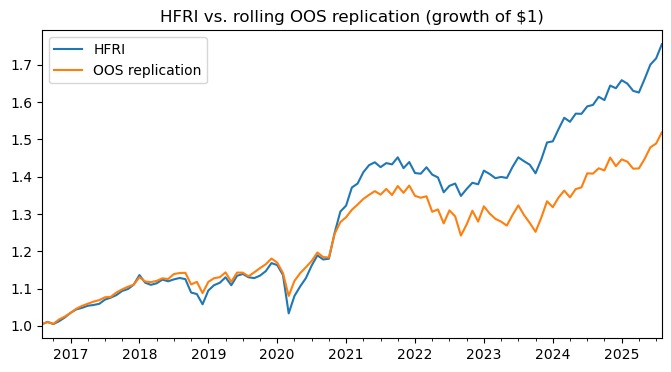

In [18]:
cum = pd.DataFrame({'HFRI': (1 + actual).cumprod(), 'OOS replication': (1 + oos).cumprod()})
cum.plot(figsize=(8, 4), title='HFRI vs. rolling OOS replication (growth of $1)')
plt.show()

Starting at month 61, for each month t I estimate the six-factor regression (with a constant) on the previous 60 months (t-60 through t-1) and use those coefficients with month t's factor returns to form the out-of-sample (OOS) replication. This gives 109 OOS months (Aug 2016 to Aug 2025). I compare this to the full-sample in-sample fit from 2.6 over the same months.

The OOS replication has a correlation of 0.90 with HFRI (0.92 in-sample), an annualized tracking error of 2.75% (2.47% in-sample) and an R-squared of 0.81 (0.85 in-sample). It underestimates HFRI's mean by 1.6% a year (4.8% versus 6.4%), compared to 0.7% in-sample.

The OOS replication performs well: it captures the direction of HFRI's returns (correlation 0.90) and misses by only slightly more than the in-sample fit, so the six-factor model is not heavily overfit. However, it is systematically too low in mean. Rolling coefficients estimated on past data lag changes in hedge-fund styles, and the regression's constant in each window cannot anticipate HFRI's average return over the next period. The fit also needs the previous 60 months to estimate, which is longer than the 24-month window Merrill uses, so a shorter window would react faster but be noisier.

---
# Unconstrained Optimization (weekly data, 52 periods per year)

In [20]:
WK = 52
G = 'spx_returns_weekly.xlsx'
tickers = ['AAPL', 'NVDA', 'MSFT', 'GOOGL', 'AMZN', 'META', 'TSLA', 'AVGO', 'BRK/B', 'LLY']
spx = pd.read_excel(G, sheet_name='spx returns', index_col=0)
add = pd.read_excel(G, sheet_name='additional returns', index_col=0)
rets = pd.concat([spx[tickers], add[['SPY']]], axis=1)    # 10 stocks + SPY
shv = add['SHV']                                          # optional: T-bill proxy
print(rets.shape, rets.index.min().date(), rets.index.max().date(), 'NaNs:', rets.isna().sum().sum())

(573, 11) 2015-07-10 2026-06-26 NaNs: 0


### 1.1 Risk statistics

In [21]:
def risk_table(df, per=WK):
    t = pd.DataFrame({'Mean (ann.)': df.mean() * per,
                      'Vol (ann.)': df.std() * np.sqrt(per)})
    t['Sharpe'] = t['Mean (ann.)'] / t['Vol (ann.)']
    t['Skewness'] = df.apply(stats.skew)
    t['Excess kurtosis'] = df.apply(stats.kurtosis)
    t['Max drawdown'] = df.apply(lambda r: max_drawdown(r)[0])   # reuses the Section 2 helper
    return t

risk_table(rets)

,Mean (ann.),Vol (ann.),Sharpe,Skewness,Excess kurtosis,Max drawdown
AAPL,0.2485,0.2776,0.8952,-0.1817,1.7785,-0.3464
NVDA,0.6453,0.4544,1.4202,0.3500,1.4683,-0.6594
MSFT,0.2353,0.2378,0.9894,0.1323,1.6598,-0.3505
GOOGL,0.2698,0.2873,0.9392,0.5312,3.0665,-0.4186
AMZN,0.2613,0.3045,0.8581,-0.0870,1.3198,-0.5483
META,0.2320,0.3575,0.6491,0.0369,3.4492,-0.7603
TSLA,0.4375,0.5797,0.7548,0.5578,1.6089,-0.7225
AVGO,0.3939,0.3825,1.0297,0.6412,3.2333,-0.4004
BRK/B,0.1348,0.1882,0.7164,-0.1860,2.5014,-0.2648
LLY,0.3014,0.2982,1.0107,0.1379,1.9485,-0.3448


Weekly total returns for 10 large-cap stocks and SPY (Jul 2015 to Jun 2026, 573 weeks). Means are annualized by x 52, volatilities by x sqrt(52), and the Sharpe ratio is the annualized mean divided by annualized volatility (total returns, as the assignment allows; subtracting SHV, which averaged about 2.0% a year, lowers all Sharpe ratios slightly without changing the picture). Kurtosis is excess kurtosis (a normal distribution gives 0). Maximum drawdown is measured on compounded wealth.

### 1.2 Most / least attractive standalone

As a standalone investment, NVDA is the most attractive: it has by far the highest Sharpe ratio (1.42) with an annualized mean return of 64.5%. AVGO (1.03) and LLY (1.01) follow. The caveat is that NVDA's risk is high (45% volatility and a -66% maximum drawdown), so it was a volatile ride. META is the least attractive: it has the lowest Sharpe ratio (0.65), 36% volatility and the deepest drawdown (-76%) for a mean return (23%) similar to MSFT's, which has a much lower volatility. BRK/B has the lowest risk of the stocks but also the lowest return, with a Sharpe ratio of 0.72, and TSLA's very high volatility (58%) leaves it with a modest 0.75 despite a 44% mean return. SPY (Sharpe 0.86) sits in the middle of the group, with the most negative skewness (-0.58) and the fattest tails (excess kurtosis 5.9).

### 1.3 Regressions vs SPY

In [23]:
def spy_regressions(df, mkt='SPY', per=WK):
    out = {}
    for c in df.columns.drop(mkt):
        res = sm.OLS(df[c], sm.add_constant(df[mkt])).fit()
        alpha, beta = res.params['const'], res.params[mkt]
        out[c] = {'Alpha (ann.)': alpha * per,
                  'Beta': beta,
                  'Info ratio': alpha * per / (res.resid.std() * np.sqrt(per)),
                  'R-squared': res.rsquared}
    return pd.DataFrame(out).T

spy_regressions(rets)

,Alpha (ann.),Beta,Info ratio,R-squared
AAPL,0.0865,1.1161,0.4247,0.4618
NVDA,0.3960,1.7179,1.1329,0.4083
MSFT,0.0878,1.0162,0.5337,0.5216
GOOGL,0.1096,1.1039,0.5016,0.4217
AMZN,0.1006,1.1066,0.4189,0.3773
META,0.0604,1.1824,0.2038,0.3125
TSLA,0.1836,1.7490,0.3683,0.2601
AVGO,0.1873,1.4231,0.6297,0.3955
BRK/B,0.0214,0.7818,0.1593,0.4927
LLY,0.2135,0.6058,0.7622,0.1179


For each stock I regress its weekly return on SPY's weekly return with an intercept (total returns). Alpha is the weekly intercept x 52, the information ratio is annualized alpha divided by annualized residual volatility (weekly residual standard deviation x sqrt(52)), and R-squared is the share of the stock's variance explained by SPY.



| | Alpha (ann.) | Beta | Info ratio | R-squared |
|---|---|---|---|---|
| AAPL | 8.6% | 1.12 | 0.43 | 0.46 |
| NVDA | 39.6% | 1.72 | 1.13 | 0.41 |
| MSFT | 8.8% | 1.02 | 0.53 | 0.52 |
| GOOGL | 11.0% | 1.10 | 0.50 | 0.42 |
| AMZN | 10.1% | 1.11 | 0.42 | 0.38 |
| META | 6.0% | 1.18 | 0.20 | 0.31 |
| TSLA | 18.4% | 1.75 | 0.37 | 0.26 |
| AVGO | 18.7% | 1.42 | 0.63 | 0.40 |
| BRK/B | 2.1% | 0.78 | 0.16 | 0.49 |
| LLY | 21.3% | 0.61 | 0.76 | 0.12 |

NVDA has the highest information ratio (1.13) and by far the largest alpha (39.6% a year), and it is the only stock whose alpha is clearly statistically significant (t-statistic of about 3.7), though it comes with a high beta of 1.72. LLY is second (information ratio 0.76, alpha 21.3%) and achieves it with a low beta of 0.61 and a low R-squared of 0.12, so its returns are largely independent of the market, making it attractive relative to just holding SPY. AVGO (0.63) is third. BRK/B (0.16) and META (0.20) are the least attractive: their alphas are small relative to their residual risk, and they would add little to a portfolio that already holds SPY.

### 2.1 Correlations

,AAPL,NVDA,MSFT,GOOGL,AMZN,META,TSLA,AVGO,BRK/B,LLY,SPY
AAPL,1.0000,0.4800,0.5500,0.5400,0.4600,0.4100,0.4400,0.5100,0.4100,0.1900,0.6800
NVDA,0.4800,1.0000,0.5900,0.4500,0.5500,0.4300,0.4100,0.5700,0.3000,0.1600,0.6400
MSFT,0.5500,0.5900,1.0000,0.6100,0.6300,0.5700,0.4100,0.5300,0.3600,0.2600,0.7200
GOOGL,0.5400,0.4500,0.6100,1.0000,0.5900,0.5100,0.3700,0.4800,0.3400,0.1700,0.6500
AMZN,0.4600,0.5500,0.6300,0.5900,1.0000,0.5300,0.4000,0.4400,0.2700,0.1400,0.6100
META,0.4100,0.4300,0.5700,0.5100,0.5300,1.0000,0.2600,0.4000,0.2800,0.1200,0.5600
TSLA,0.4400,0.4100,0.4100,0.3700,0.4000,0.2600,1.0000,0.3700,0.2000,0.1300,0.5100
AVGO,0.5100,0.5700,0.5300,0.4800,0.4400,0.4000,0.3700,1.0000,0.3000,0.1000,0.6300
BRK/B,0.4100,0.3000,0.3600,0.3400,0.2700,0.2800,0.2000,0.3000,1.0000,0.3000,0.7000
LLY,0.1900,0.1600,0.2600,0.1700,0.1400,0.1200,0.1300,0.1000,0.3000,1.0000,0.3400


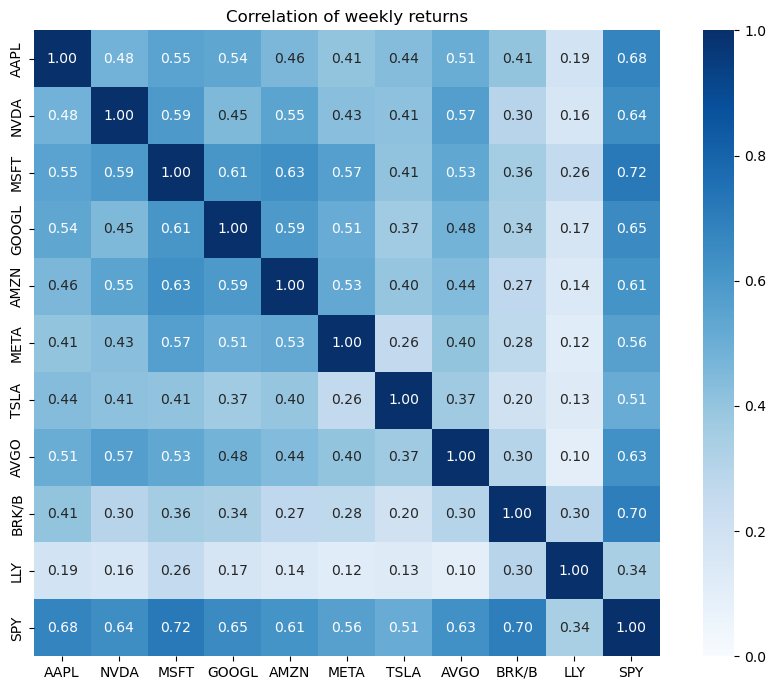

Minimally correlated: ('AVGO', 'LLY') 0.104
Maximally correlated: ('MSFT', 'SPY') 0.722

Average correlation with the other assets (lowest first):
LLY     0.1910
BRK/B   0.3450
TSLA    0.3490
META    0.4060
AVGO    0.4350
NVDA    0.4590
AMZN    0.4620
AAPL    0.4660
GOOGL   0.4700
MSFT    0.5230
SPY     0.6050
dtype: float64


In [24]:
corr = rets.corr()
display(corr.round(2))

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1, square=True)
plt.title('Correlation of weekly returns')
plt.tight_layout()
plt.show()

off = corr.where(~np.eye(len(corr), dtype=bool)).stack()
off = off[[a < b for a, b in off.index]].sort_values()
print('Minimally correlated:', off.index[0], round(off.iloc[0], 3))
print('Maximally correlated:', off.index[-1], round(off.iloc[-1], 3))

print('\nAverage correlation with the other assets (lowest first):')
print(corr.where(~np.eye(len(corr), dtype=bool)).mean().sort_values().round(3))

The correlation matrix of weekly returns for the 10 stocks and SPY is shown above. All correlations are positive. The maximally correlated pair is MSFT and SPY (0.72); among the individual stocks it is MSFT and AMZN (0.63). The minimally correlated pair is AVGO and LLY (0.10).

LLY should receive extra weight in the optimized portfolio beyond what its mean return alone merits. It has by far the lowest average correlation with the other assets (0.19, versus 0.35 to 0.52 for most others) and is only weakly correlated with every stock (0.10 to 0.30), so it contributes the most diversification per unit of risk. BRK/B (average correlation 0.35) and TSLA (0.35) are the next least correlated. The large technology stocks (MSFT, GOOGL, AMZN, AAPL) are highly correlated with one another and with SPY, so the optimizer is expected to give them less weight than their returns alone would suggest.

### 2.2 Tangency portfolio

In [25]:
def tangency(rets, per=WK):
    mu = rets.mean() * per
    Sigma = rets.cov() * per
    w = np.linalg.solve(Sigma.values, mu.values)       # proportional to Sigma^-1 mu
    return pd.Series(w / w.sum(), index=rets.columns)  # normalize to sum to 1

w_opt = tangency(rets)
sharpes = (rets.mean() * WK) / (rets.std() * np.sqrt(WK))
table = pd.DataFrame({'Optimal weight': w_opt, 'Sharpe (ann.)': sharpes})
display(table.round(3))
print('Sum of weights:', round(w_opt.sum(), 6))
print('Rank correlation between weight and Sharpe:', round(table.corr(method='spearman').iloc[0, 1], 2))

,Optimal weight,Sharpe (ann.)
AAPL,0.3530,0.8950
NVDA,0.8460,1.4200
MSFT,0.3010,0.9890
GOOGL,0.5510,0.9390
AMZN,0.1290,0.8580
META,0.1000,0.6490
TSLA,0.2000,0.7550
AVGO,0.4540,1.0300
BRK/B,1.6960,0.7160
LLY,0.9050,1.0110


Sum of weights: 1.0
Rank correlation between weight and Sharpe: 0.44


The tangency (mean-variance optimal) portfolio has weights proportional to the inverse covariance matrix times the vector of mean returns, normalized to sum to one. I use the annualized mean returns and covariance matrix of the 10 stocks and SPY (total returns, no risk-free rate, as the assignment allows).

See the table above. The weights are extreme: SPY receives a -454% short position, financing long positions of 170% in BRK/B, 91% in LLY, 85% in NVDA, 55% in GOOGL, 45% in AVGO and smaller positions in the others (the weights sum to 100%).

Only loosely. NVDA has by far the best standalone Sharpe ratio (1.42) and gets a large weight (85%), but BRK/B, which has one of the lowest Sharpe ratios (0.72), gets the largest weight (170%) because it is weakly correlated with the rest. LLY (Sharpe 1.01) gets more weight than MSFT (0.99) or AVGO (1.03) because it is the least correlated with the others, as discussed in 2.1. Conversely, META, which has the lowest Sharpe ratio, receives the smallest long position (10%). The optimizer's weights reflect both each asset's expected return per unit of risk and how it diversifies the others, so a high standalone Sharpe ratio is not enough. SPY's huge short position reflects that it is nearly a combination of the stocks already in the portfolio, so it is used as a hedge.

### 2.3 Portfolio performance

In [26]:
port = rets @ w_opt
port_stats = pd.Series({'Mean (ann.)': port.mean() * WK,
                        'Vol (ann.)': port.std() * np.sqrt(WK),
                        'Sharpe (ann.)': port.mean() * WK / (port.std() * np.sqrt(WK))})
display(port_stats.round(4))

Mean (ann.)     1.0201
Vol (ann.)      0.5222
Sharpe (ann.)   1.9536
dtype: float64

I apply the tangency weights from 2.2 to the weekly returns of the 11 assets and compute the annualized mean (x 52), volatility (x sqrt(52)) and Sharpe ratio of the resulting portfolio.

The optimized portfolio has an annualized mean of 102.0%, an annualized volatility of 52.2% and a Sharpe ratio of 1.95. This is well above the best standalone Sharpe ratio (NVDA's 1.42) and SPY's 0.86, showing the gain from diversification. The high mean and volatility reflect the leverage in the weights (about 554% long and 454% short).

The weights are estimated from the same sample that is used to evaluate the portfolio, so these figures are in-sample and optimistic. Out of sample, the performance would be lower because the estimated means and covariances are noisy and the weights are extreme.

### 2.4 Dropping the biggest short

In [27]:
rets_nospy = rets.drop(columns='SPY')
w_nospy = tangency(rets_nospy)

compare = pd.DataFrame({'With SPY': w_opt, 'Without SPY': w_nospy})
display(compare.round(3))

def port_summary(w, df):
    p = df[w.index] @ w
    return {'Mean (ann.)': p.mean() * WK, 'Vol (ann.)': p.std() * np.sqrt(WK),
            'Sharpe (ann.)': p.mean() * WK / (p.std() * np.sqrt(WK)),
            'Long': w[w > 0].sum(), 'Short': w[w < 0].sum(), 'Gross': w.abs().sum()}

display(pd.DataFrame({'With SPY': port_summary(w_opt, rets),
                      'Without SPY': port_summary(w_nospy, rets)}).T.round(3))

# Why: SPY is largely explained by the stocks, which makes the covariance matrix near-singular
res = sm.OLS(rets['SPY'], sm.add_constant(rets_nospy)).fit()
print('R-squared of SPY on the 10 stocks:', round(res.rsquared, 3))
print('Residual vol (ann.):', round(res.resid.std() * np.sqrt(WK), 4), ' SPY vol (ann.):', round(rets['SPY'].std() * np.sqrt(WK), 4))
print('Condition number with SPY:', round(np.linalg.cond(rets.cov().values), 1),
      ' without:', round(np.linalg.cond(rets_nospy.cov().values), 1))

,With SPY,Without SPY
AAPL,0.3530,0.0060
AMZN,0.1290,-0.0340
AVGO,0.4540,0.1120
BRK/B,1.6960,0.0390
GOOGL,0.5510,0.1770
LLY,0.9050,0.4310
META,0.1000,-0.0450
MSFT,0.3010,-0.1130
NVDA,0.8460,0.4050
SPY,-4.5380,NaN


,Mean (ann.),Vol (ann.),Sharpe (ann.),Long,Short,Gross
With SPY,1.0200,0.5220,1.9540,5.5380,-4.5380,10.0750
Without SPY,0.4540,0.2720,1.6660,1.1920,-0.1920,1.3850


R-squared of SPY on the 10 stocks: 0.873
Residual vol (ann.): 0.0601  SPY vol (ann.): 0.169
Condition number with SPY: 206.8  without: 30.3


SPY has the biggest short position (-454%), so I drop it and re-run the tangency optimization on the 10 stocks. The new weights are much more moderate: gross exposure falls from about 10.1x to 1.4x, with longs of 119% and shorts of only 19%. The weight is now concentrated in LLY (43%), NVDA (41%), GOOGL (18%) and AVGO (11%), with small shorts in MSFT (-11%), META (-4.5%) and AMZN (-3%). BRK/B drops from 170% to 4%. The portfolio's Sharpe ratio falls from 1.95 to 1.67 (mean 45% and volatility 27%, versus 102% and 52%).

SPY is largely a combination of the stocks already in the investment set: regressing SPY on the 10 stocks gives an R-squared of 0.87, and the residual volatility is only 6.0% (versus 16.9% for SPY itself). With such a nearly redundant asset the covariance matrix is close to singular (condition number of 207, versus 30 without SPY), and the inverse covariance matrix amplifies small differences. The optimizer exploited the small residual with very large offsetting long and short positions (a huge short in SPY financing large longs, notably BRK/B), which scales up estimation error in the means and covariances. So the extreme weights and the higher Sharpe ratio with SPY largely reflect leverage on in-sample noise, not a better portfolio. Mean-variance optimization without constraints is therefore unstable when assets are highly correlated, and the weights should not be trusted as stated. The no-SPY weights are far more implementable, though they are also estimated in-sample and still sensitive to the noisy mean estimates.